<a href="https://colab.research.google.com/github/heetaamin/Assignment-3/blob/main/Glass/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 100)
plt.rcParams["figure.dpi"] = 110

# Load the file

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

data_dir = '/content/drive/MyDrive/Colab Notebooks/Machine Learning/Assignment 3/Glass/'

cols = ["Id", "RI", "Na", "Mg", "Al", "Si", "K", "Ca", "Ba", "Fe", "Type"]
df_raw = pd.read_csv(data_dir + "glass.data", names=cols)
df_raw = df_raw.drop(columns=["Id"])
print("Shape:", df_raw.shape)
df_raw.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (214, 10)


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


# Basic dataset structure

In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


The 9 descriptive features are floats which is right since they are continuous values while the target is an integer which is expected as well

# Target value exploration

In [ ]:
print("Target variable:", "Type")
print("Unique classes:", sorted(df_raw["Type"].unique()))
print("Number of classes:", df_raw["Type"].nunique())
df_raw["Type"].value_counts().sort_index()

Target variable: Type
Unique classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(7)]
Number of classes: 6


,count
Type,
1,70
2,76
3,17
5,13
6,9
7,29


From this we see that class 4 is absent and so we have 6 classes

# Missing values check

In [ ]:
# From the code exploring the dataset we already see there are no missing values but we can confirm this here

print("Missing values (total):", df_raw.isna().sum().sum())
df_raw.isna().sum()

Missing values (total): 0


,0
RI,0
Na,0
Mg,0
Al,0
Si,0
K,0
Ca,0
Ba,0
Fe,0
Type,0


# Exact duplicate rows check

In [ ]:
dup_mask = df_raw.duplicated(keep=False)
print(f"Duplicate rows: {df_raw.duplicated().sum()}")
df_raw[dup_mask]

Duplicate rows: 1


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
38,1.52213,14.21,3.82,0.47,71.77,0.11,9.57,0.0,0.0,1
39,1.52213,14.21,3.82,0.47,71.77,0.11,9.57,0.0,0.0,1


One exact duplicate pair and they are both class 1, which is one of the majority classes. The duplicate observation was removed to prevent the same observation from potentially appearing in both the training and test sets. Removal of this also does not affect the minority to majority class ordering.

In [ ]:
df = df_raw.drop_duplicates().reset_index(drop=True)
print("Shape after dropping the duplicate:", df.shape)

Shape after dropping the duplicate: (213, 10)


# Duplicate feature vectors with different labels check

In [ ]:
feature_cols = [c for c in df.columns if c != "Type"]
feature_dup_mask = df.duplicated(subset=feature_cols, keep=False)
print("Rows with identical features but (possibly) different labels:", feature_dup_mask.sum())
df[feature_dup_mask].sort_values(feature_cols)

Rows with identical features but (possibly) different labels: 0


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type


This is just to check if there is an irreducible error present

# Class distribution and minority to majority ordering

In [ ]:
CLASS_NAMES = {1: "bldg_float", 2: "bldg_nonfloat", 3: "vehicle_float",
               5: "containers", 6: "tableware", 7: "headlamps"}

counts = df["Type"].value_counts().sort_values()
total = len(df)
dist_table = pd.DataFrame({
    "class_label": counts.index,
    "class_name": [CLASS_NAMES[c] for c in counts.index],
    "count": counts.values,
    "pct": (counts.values / total * 100).round(2),
})
dist_table["rank_minority_to_majority"] = range(1, len(dist_table) + 1)
dist_table

,class_label,class_name,count,pct,rank_minority_to_majority
0,6,tableware,9,4.23,1
1,5,containers,13,6.10,2
2,3,vehicle_float,17,7.98,3
3,7,headlamps,29,13.62,4
4,1,bldg_float,69,32.39,5
5,2,bldg_nonfloat,76,35.68,6


# Ordering and the imbalance ratio


In [ ]:
minority_to_majority_order = dist_table["class_label"].tolist()
imbalance_ratio = counts.max() / counts.min()

print("Minority -> majority order:", [CLASS_NAMES[c] for c in minority_to_majority_order])
print(f"Imbalance ratio (majority/minority): {imbalance_ratio:.2f}")

Minority -> majority order: ['tableware', 'containers', 'vehicle_float', 'headlamps', 'bldg_float', 'bldg_nonfloat']
Imbalance ratio (majority/minority): 8.44


# Class distribution bar chat

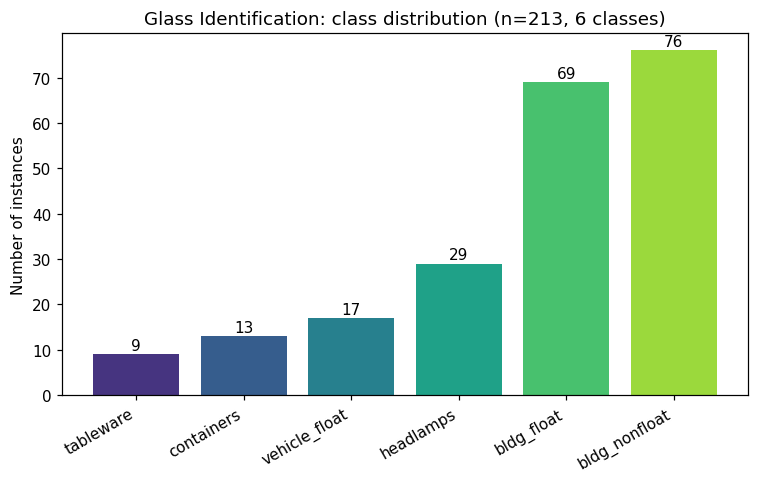

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(dist_table)))
ax.bar(dist_table["class_name"], dist_table["count"], color=colors)
for i, v in enumerate(dist_table["count"]):
    ax.text(i, v + 1, str(v), ha="center", fontsize=10)
ax.set_ylabel("Number of instances")
ax.set_title(f"Glass Identification: class distribution (n={total}, 6 classes)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Descriptive statistics

In [ ]:
def continuous_dqr(df, cols):
    n = len(df)
    rows = []
    for c in cols:
        s = df[c]
        count = s.count()
        rows.append({
            "Feature": c, "Count": count, "% Miss.": round((n - count) / n * 100, 2),
            "Card.": s.nunique(), "Min.": s.min(), "1st Qrt.": s.quantile(0.25),
            "Mean": s.mean(), "Median": s.median(), "3rd Qrt.": s.quantile(0.75),
            "Max.": s.max(), "Std. Dev.": s.std(),
        })
    out = pd.DataFrame(rows)
    num_cols = ["Min.", "1st Qrt.", "Mean", "Median", "3rd Qrt.", "Max.", "Std. Dev."]
    out[num_cols] = out[num_cols].round(3)
    return out

def categorical_dqr(df, cols, label_map=None):
    n = len(df)
    rows = []
    for c in cols:
        s = df[c]
        count = s.count()
        vc = s.value_counts()
        mode, mode_freq = vc.index[0], int(vc.iloc[0])
        mode_pct = round(mode_freq / count * 100, 2)
        if len(vc) > 1:
            mode2, mode2_freq = vc.index[1], int(vc.iloc[1])
            mode2_pct = round(mode2_freq / count * 100, 2)
        else:
            mode2, mode2_freq, mode2_pct = np.nan, 0, 0.0
        if label_map:
            mode = f"{mode} ({label_map.get(mode, mode)})"
            mode2 = f"{mode2} ({label_map.get(mode2, mode2)})" if pd.notna(mode2) else mode2
        rows.append({
            "Feature": c, "Count": count, "% Miss.": round((n - count) / n * 100, 2),
            "Card.": s.nunique(), "Mode": mode, "Mode Freq.": mode_freq, "Mode %": mode_pct,
            "2nd Mode": mode2, "2nd Mode Freq.": mode2_freq, "2nd Mode %": mode2_pct,
        })
    return pd.DataFrame(rows)

# Descriptive features: all 9 are continuous — no categorical descriptive
# features in this dataset, so there is no separate descriptive-categorical table.
continuous_dqr_table = continuous_dqr(df, feature_cols)

# Type is the TARGET, not a descriptive feature — its own table, same
# column order as the categorical DQR format.
target_dqr_table = categorical_dqr(df, ["Type"], label_map=CLASS_NAMES)

print("Continuous Descriptive Features — Data Quality Report")
display(continuous_dqr_table)

print("Target Feature — Data Quality Report")
display(target_dqr_table)

Continuous Descriptive Features — Data Quality Report


,Feature,Count,% Miss.,Card.,Min.,1st Qrt.,Mean,Median,3rd Qrt.,Max.,Std. Dev.
0,RI,213,0.0,178,1.511,1.517,1.518,1.518,1.519,1.534,0.003
1,Na,213,0.0,142,10.730,12.900,13.404,13.300,13.810,17.380,0.817
2,Mg,213,0.0,94,0.000,2.090,2.679,3.480,3.600,4.490,1.444
3,Al,213,0.0,118,0.290,1.190,1.449,1.360,1.630,3.500,0.496
4,Si,213,0.0,133,69.810,72.280,72.655,72.790,73.090,75.410,0.774
5,K,213,0.0,65,0.000,0.130,0.499,0.560,0.610,6.210,0.653
6,Ca,213,0.0,143,5.430,8.240,8.954,8.600,9.150,16.190,1.426
7,Ba,213,0.0,34,0.000,0.000,0.176,0.000,0.000,3.150,0.498
8,Fe,213,0.0,32,0.000,0.000,0.057,0.000,0.100,0.510,0.098


Target Feature — Data Quality Report


,Feature,Count,% Miss.,Card.,Mode,Mode Freq.,Mode %,2nd Mode,2nd Mode Freq.,2nd Mode %
0,Type,213,0.0,6,2 (bldg_nonfloat),76,35.68,1 (bldg_float),69,32.39


# Outlier check via IQR

In [ ]:
Q1 = df[feature_cols].quantile(0.25)
Q3 = df[feature_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_counts = (
    ((df[feature_cols] < (Q1 - 1.5 * IQR)) | (df[feature_cols] > (Q3 + 1.5 * IQR)))
    .sum()
    .sort_values(ascending=False)
)
outlier_counts

,0
Ba,38
Ca,27
RI,17
Al,17
Si,12
Fe,12
Na,7
K,7
Mg,0


Some of these features contain outliers but they are not removed as they may represent legitimate glass compositions. However we mark them so we can refer back to them incase a class is hard to learn

# Correlation matrix

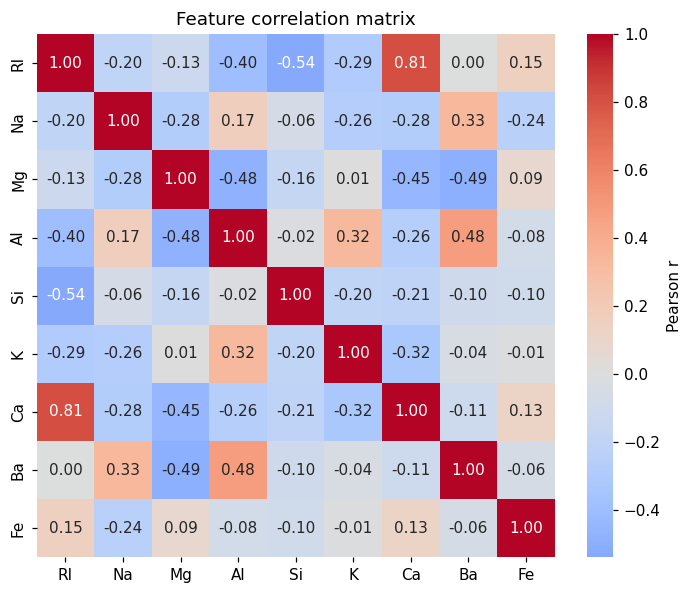

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
corr = df[feature_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
            cbar_kws={"label": "Pearson r"})
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

# Feature distribution by class

Type is categorical so we cannot use Pearson correlation, box plots are the right method to see whether a feature discrimnates between classes

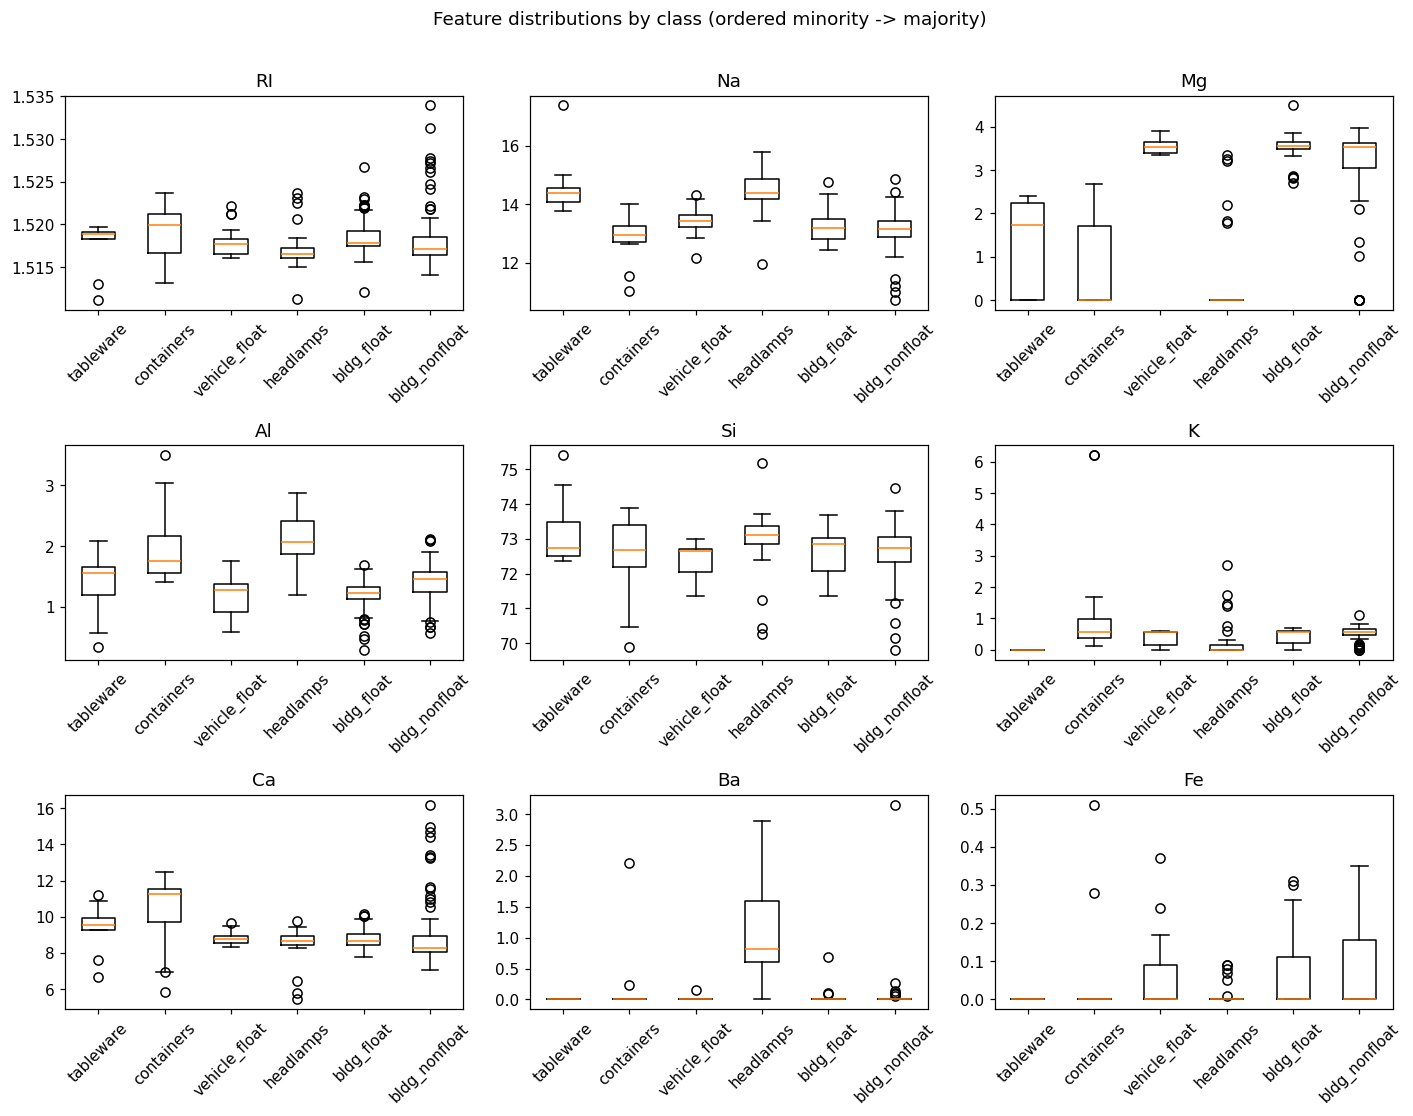

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
axes = axes.flatten()
for i, feat in enumerate(feature_cols):
    data_by_class = [df[df["Type"] == c][feat].values for c in minority_to_majority_order]
    axes[i].boxplot(data_by_class, tick_labels=[CLASS_NAMES[c] for c in minority_to_majority_order])
    axes[i].set_title(feat)
    axes[i].tick_params(axis="x", rotation=45)
plt.suptitle("Feature distributions by class (ordered minority -> majority)", y=1.01)
plt.tight_layout()
plt.show()

Here we are looking if the boxes for different classes sit at different heights for each descriptive feature.

Mg is the most discrimantive feature

Ri and Si are not really useful in providing information to seperate the classes. The 6 classes boxes basically sit at the same level

# Saving the data

In [ ]:
df.to_csv(data_dir + "glass_clean.csv", index=False)
dist_table.to_csv(data_dir + "class_distribution.csv", index=False)
print(f"Saved to {data_dir}")

Saved to /content/drive/MyDrive/Colab Notebooks/Machine Learning/Assignment 3/Glass/
